# AI Final Project: Flower Image Classification using SVM and CNN
By: Sarah Ogden and Elaina Hall

# Import Data

In [5]:
import os
import numpy as np
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
from PIL import Image

# Define paths
TRAIN_DIR = 'dataset_split/train'
TEST_DIR = 'dataset_split/test'

# Count images per class
def count_images(root_dir):
    counts = defaultdict(int)
    for class_dir in Path(root_dir).iterdir():
        if class_dir.is_dir():
            images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpeg'))
            counts[class_dir.name] = len(images)
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print("Training set - Images per class:")
for cls in sorted(train_counts.keys()):
    print(f"  {cls}: {train_counts[cls]}")
print(f"\nTotal train: {sum(train_counts.values())}")

print("\nTest set - Images per class:")
for cls in sorted(test_counts.keys()):
    print(f"  {cls}: {test_counts[cls]}")
print(f"\nTotal test: {sum(test_counts.values())}")

# Verify image sizes
print("\nSample image dimensions:")
for cls in list(train_counts.keys())[:3]:
    img_files = list((Path(TRAIN_DIR) / cls).glob('*.*'))
    if img_files:
        img = Image.open(img_files[0])
        print(f"  {cls}: {img.size}")

Training set - Images per class:
  astilbe: 515
  bellflower: 606
  black_eyed_susan: 700
  calendula: 683
  california_poppy: 715
  carnation: 645
  common_daisy: 686
  coreopsis: 732
  daffodil: 679
  dandelion: 1156
  iris: 737
  lavender: 274
  lilly: 343
  lotus: 349
  magnolia: 733
  orchid: 338
  rose: 1048
  sunflower: 1068
  tulip: 1075
  water_lily: 686

Total train: 13768

Test set - Images per class:
  astilbe: 222
  bellflower: 261
  black_eyed_susan: 300
  calendula: 294
  california_poppy: 307
  carnation: 277
  common_daisy: 294
  coreopsis: 315
  daffodil: 291
  dandelion: 496
  iris: 317
  lavender: 118
  lilly: 148
  lotus: 150
  magnolia: 315
  orchid: 146
  rose: 450
  sunflower: 459
  tulip: 461
  water_lily: 295

Total test: 5916

Sample image dimensions:
  astilbe: (256, 256)
  bellflower: (256, 256)
  black_eyed_susan: (256, 256)


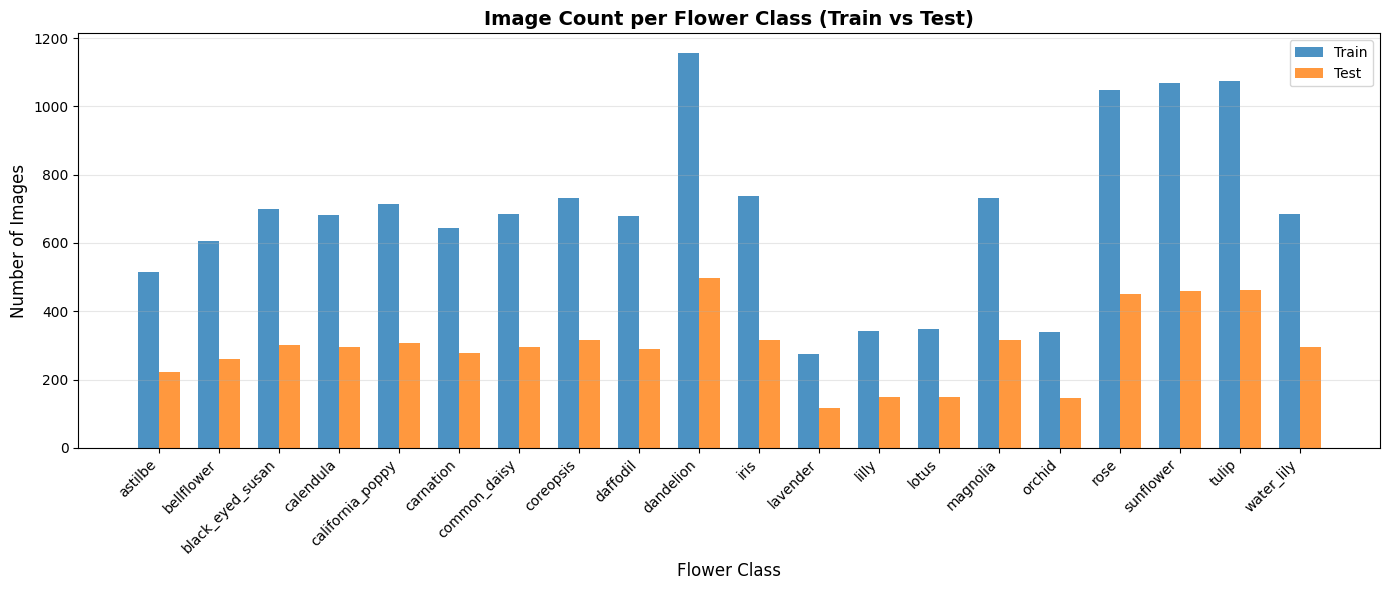


Summary Statistics:
Class                   Train     Test    Total    Train %
--------------------------------------------------------
astilbe                   515      222      737      69.9%
bellflower                606      261      867      69.9%
black_eyed_susan          700      300     1000      70.0%
calendula                 683      294      977      69.9%
california_poppy          715      307     1022      70.0%
carnation                 645      277      922      70.0%
common_daisy              686      294      980      70.0%
coreopsis                 732      315     1047      69.9%
daffodil                  679      291      970      70.0%
dandelion                1156      496     1652      70.0%
iris                      737      317     1054      69.9%
lavender                  274      118      392      69.9%
lilly                     343      148      491      69.9%
lotus                     349      150      499      69.9%
magnolia                  733      31

In [6]:
# Visualization

classes = sorted(train_counts.keys())
train_vals = [train_counts[cls] for cls in classes]
test_vals = [test_counts[cls] for cls in classes]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, train_vals, width, label='Train', alpha=0.8)
bars2 = ax.bar(x + width/2, test_vals, width, label='Test', alpha=0.8)

ax.set_xlabel('Flower Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Image Count per Flower Class (Train vs Test)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary stats
print("\nSummary Statistics:")
print(f"{'Class':<20} {'Train':>8} {'Test':>8} {'Total':>8} {'Train %':>10}")
print("-" * 56)
for cls in classes:
    train_c = train_counts[cls]
    test_c = test_counts[cls]
    total = train_c + test_c
    train_pct = (train_c / total) * 100
    print(f"{cls:<20} {train_c:>8} {test_c:>8} {total:>8} {train_pct:>9.1f}%")

# SVM Model

Found 13768 images belonging to 20 classes.
Found 5916 images belonging to 20 classes.
Found 5916 images belonging to 20 classes.
216/216 ━━━━━━━━━━━━━━━━━━━━ 169s 781ms/step
93/93 ━━━━━━━━━━━━━━━━━━━━ 76s 823ms/step
Applying PCA to reduce dimensionality from 1280 to 256...
PCA explained variance ratio: 1.0000

Training RBF SVM (this may take 5-10 minutes)...
[LibSVM]Training completed in 13.24 seconds

RBF SVM Accuracy: 0.3676

Classification Report:
              precision    recall  f1-score   support

           0       0.24      0.41      0.30       222
           1       0.27      0.24      0.25       261
           2       0.53      0.56      0.54       300
           3       0.33      0.29      0.31       294
           4       0.31      0.39      0.35       307
           5       0.25      0.14      0.18       277
           6       0.38      0.35      0.36       294
           7       0.40      0.44      0.42       315
           8       0.35      0.43      0.39       291
   

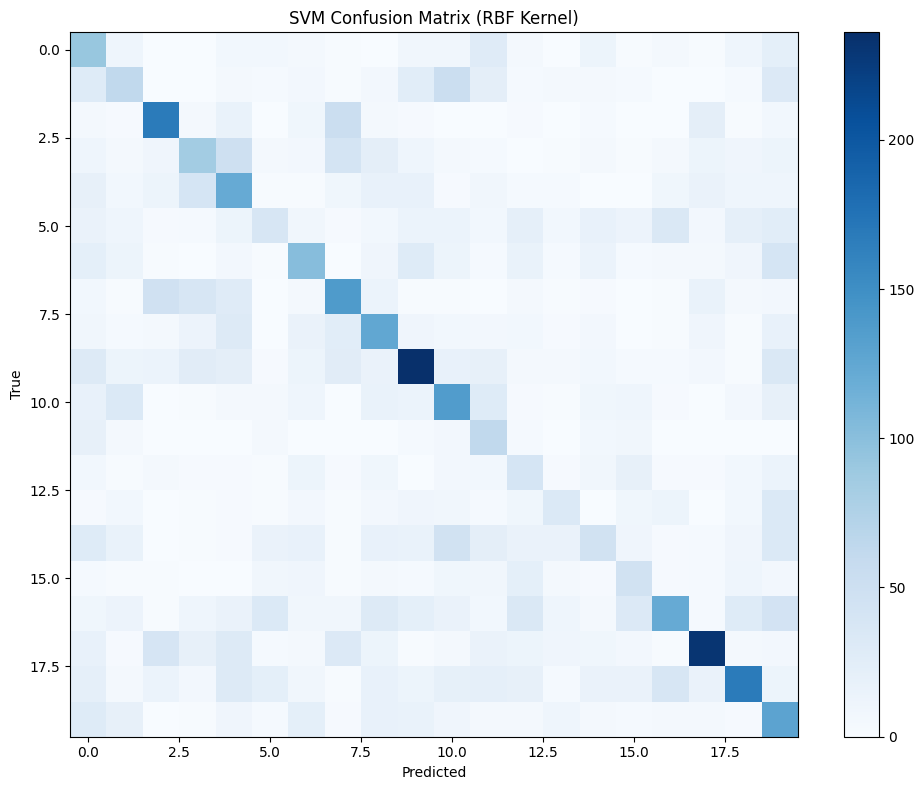

In [2]:
# Extract bottleneck features and train a non-linear (RBF) SVM
import numpy as np
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Model
from pathlib import Path
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA
import joblib
import time

TRAIN_DIR = 'dataset_split/train'
TEST_DIR = 'dataset_split/test'
BATCH_SIZE = 64
TARGET_SIZE = (224, 224)
FEATURE_FILE_TRAIN = 'features_train.npy'
FEATURE_FILE_TEST = 'features_test.npy'
LABELS_FILE_TRAIN = 'labels_train.npy'
LABELS_FILE_TEST = 'labels_test.npy'

# 1) Build feature extractor (remove top, use global pooling)
base = EfficientNetB0(weights='imagenet', include_top=False, pooling='avg', input_shape=(224,224,3))
feature_model = Model(base.input, base.output)  # pooling='avg' gives (batch, 1280)

# 2) Generators (no augmentation for features)
datagen = ImageDataGenerator(rescale=1./255)
train_gen = datagen.flow_from_directory(TRAIN_DIR, target_size=TARGET_SIZE,
                                        batch_size=BATCH_SIZE, class_mode='sparse', shuffle=False)
test_gen = datagen.flow_from_directory(TEST_DIR, target_size=TARGET_SIZE,
                                       batch_size=BATCH_SIZE, class_mode='sparse', shuffle=False)

# 3) Extract and save features (predict on generator)
def extract_features(gen, steps, out_feat, out_labels):
    features = feature_model.predict(gen, steps=steps, verbose=1)
    labels = gen.labels  # when shuffle=False, labels align with predict order
    np.save(out_feat, features.astype(np.float32))
    np.save(out_labels, labels.astype(np.int32))
    return features, labels

train_steps = int(np.ceil(train_gen.samples / BATCH_SIZE))
test_steps = int(np.ceil(test_gen.samples / BATCH_SIZE))

X_train, y_train = extract_features(train_gen, train_steps, FEATURE_FILE_TRAIN, LABELS_FILE_TRAIN)
X_test, y_test = extract_features(test_gen, test_steps, FEATURE_FILE_TEST, LABELS_FILE_TEST)

# 4) PCA to reduce dims (required for RBF SVM to fit in memory)
print("Applying PCA to reduce dimensionality from 1280 to 256...")
pca = PCA(n_components=256, svd_solver='randomized', whiten=False)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
joblib.dump(pca, 'pca.joblib')
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

# 5) Train non-linear (RBF) SVC
print("\nTraining RBF SVM (this may take 5-10 minutes)...")
classes = np.unique(y_train)
class_weights = dict(enumerate(compute_class_weight('balanced', classes=classes, y=y_train)))
svc = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight=class_weights, verbose=1)
start_time = time.time()
svc.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds")

# 6) Save model
joblib.dump(svc, 'svm_rbf_bottleneck.joblib')

# 7) Evaluate
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
y_pred = svc.predict(X_test)
svm_accuracy = accuracy_score(y_test, y_pred)
print(f'\nRBF SVM Accuracy: {svm_accuracy:.4f}')
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# 8) Optional: Plot confusion matrix for top classes
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues', aspect='auto')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('SVM Confusion Matrix (RBF Kernel)')
plt.tight_layout()
plt.show()


# CNN Model

Creating quick subset with 550 images per class (total depends on number of classes)...
Train: 400 per class | Test: 150 per class

Skipping astilbe (only 515 images)
bellflower: 400 train, 150 test
black_eyed_susan: 400 train, 150 test
bellflower: 400 train, 150 test
black_eyed_susan: 400 train, 150 test
calendula: 400 train, 150 test
california_poppy: 400 train, 150 test
calendula: 400 train, 150 test
california_poppy: 400 train, 150 test
carnation: 400 train, 150 test
carnation: 400 train, 150 test
common_daisy: 400 train, 150 test
common_daisy: 400 train, 150 test
coreopsis: 400 train, 150 test
daffodil: 400 train, 150 test
coreopsis: 400 train, 150 test
daffodil: 400 train, 150 test
dandelion: 400 train, 150 test
dandelion: 400 train, 150 test
iris: 400 train, 150 test
Skipping lavender (only 274 images)
Skipping lilly (only 343 images)
Skipping lotus (only 349 images)
iris: 400 train, 150 test
Skipping lavender (only 274 images)
Skipping lilly (only 343 images)
Skipping lotus (on

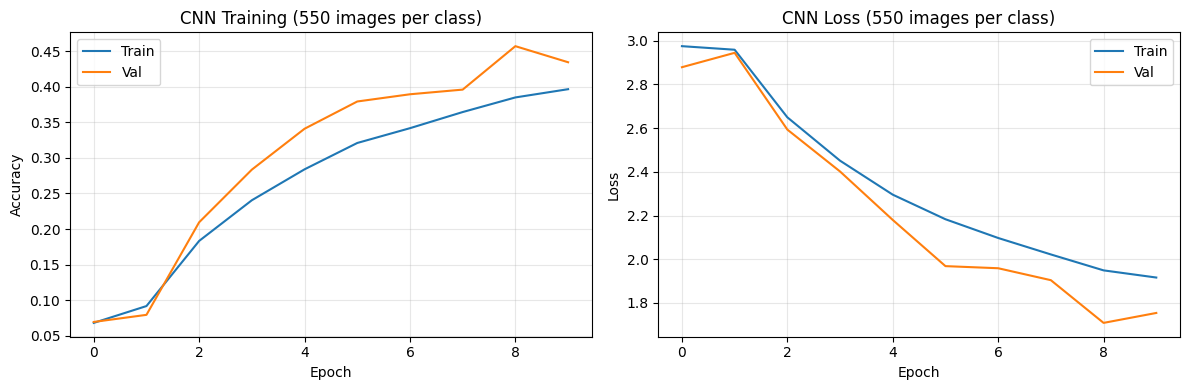

In [3]:
import shutil
from pathlib import Path
import random
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Create subset directories (550 images per class: 400 train, 150 test)
QUICK_TRAIN_DIR = 'dataset_quick/train'
QUICK_TEST_DIR = 'dataset_quick/test'

# Create directories
Path(QUICK_TRAIN_DIR).mkdir(parents=True, exist_ok=True)
Path(QUICK_TEST_DIR).mkdir(parents=True, exist_ok=True)

# Get all flower classes
flower_classes = sorted([d.name for d in Path('dataset_split/train').iterdir() if d.is_dir()])

print(f"Creating quick subset with 550 images per class (total depends on number of classes)...")
print(f"Train: 400 per class | Test: 150 per class\n")

for cls in flower_classes:
    # Create class directories
    Path(f'{QUICK_TRAIN_DIR}/{cls}').mkdir(parents=True, exist_ok=True)
    Path(f'{QUICK_TEST_DIR}/{cls}').mkdir(parents=True, exist_ok=True)
    
    # Get all images for this class
    all_images = list(Path(f'dataset_split/train/{cls}').glob('*.*'))
    random.shuffle(all_images)
    
    # Skip classes with fewer than 550 images
    if len(all_images) < 550:
        print(f"Skipping {cls} (only {len(all_images)} images)")
        continue
    
    # Split: 400 train, 150 test
    train_images = all_images[:400]
    test_images = all_images[400:550]
    
    # Copy to quick directories
    for img in train_images:
        shutil.copy2(img, f'{QUICK_TRAIN_DIR}/{cls}/{img.name}')
    for img in test_images:
        shutil.copy2(img, f'{QUICK_TEST_DIR}/{cls}/{img.name}')
    
    print(f"{cls}: {len(train_images)} train, {len(test_images)} test")

print(f"\nQuick dataset created!")
print(f"Train: {len(list(Path(QUICK_TRAIN_DIR).rglob('*.*')))} images")
print(f"Test: {len(list(Path(QUICK_TEST_DIR).rglob('*.*')))} images")

# Train CNN on quick dataset
quick_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

quick_test_datagen = ImageDataGenerator(rescale=1./255)

quick_train_generator = quick_train_datagen.flow_from_directory(
    QUICK_TRAIN_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

quick_test_generator = quick_test_datagen.flow_from_directory(
    QUICK_TEST_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# Build CNN
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
out = layers.Dense(quick_train_generator.num_classes, activation='softmax')(x)

cnn_quick = models.Model(base_model.input, out)
cnn_quick.compile(optimizer=optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Phase 1: Frozen (1 epoch)
print("\nPhase 1: Training with frozen backbone (1 epoch)...")
history1_quick = cnn_quick.fit(
    quick_train_generator,
    validation_data=quick_test_generator,
    epochs=1,
    verbose=1
)

# Phase 2: Fine-tune
print("\nPhase 2: Fine-tuning (9 epochs)...")
num_layers = len(base_model.layers)
for layer in base_model.layers[:num_layers // 2]:
    layer.trainable = False
for layer in base_model.layers[num_layers // 2:]:
    layer.trainable = True

cnn_quick.compile(optimizer=optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

history2_quick = cnn_quick.fit(
    quick_train_generator,
    validation_data=quick_test_generator,
    epochs=9,
    verbose=1
)

# Evaluate
cnn_quick_loss, cnn_quick_accuracy = cnn_quick.evaluate(quick_test_generator)
print(f"\nCNN Accuracy (550 images per class): {cnn_quick_accuracy:.4f} ({cnn_quick_accuracy*100:.2f}%)")

# Plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history1_quick.history['accuracy'] + history2_quick.history['accuracy'], label='Train')
plt.plot(history1_quick.history['val_accuracy'] + history2_quick.history['val_accuracy'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('CNN Training (550 images per class)')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history1_quick.history['loss'] + history2_quick.history['loss'], label='Train')
plt.plot(history1_quick.history['val_loss'] + history2_quick.history['val_loss'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('CNN Loss (550 images per class)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()